### Inference


image 1/1 /workspace/irobman2526-finalproject/test/Screenshot from 2026-03-20 10-19-08.png: 640x640 1 traffic light, 1 sports ball, 1 orange, 7.1ms
Speed: 3.2ms preprocess, 7.1ms inference, 0.4ms postprocess per image at shape (1, 3, 640, 640)


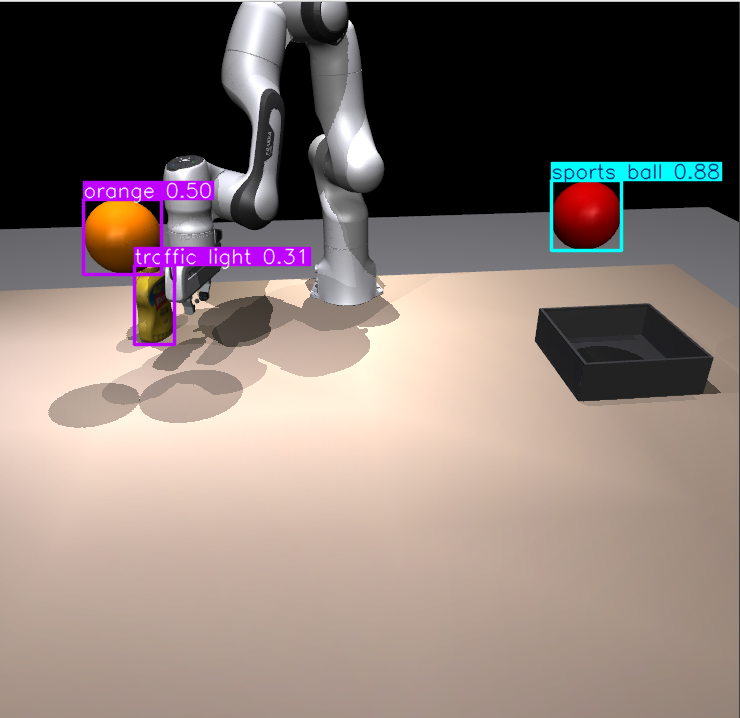

In [6]:
from ultralytics import YOLO

# Load a model
# model = YOLO("yolo26n-obb.yaml").load("yolo26n.pt")  # load an official model
model = YOLO("yolo26n.pt")  # load an official model
# model = YOLO("path/to/best.pt")  # load a custom model

# Predict with the model
# results = model("/workspace/irobman2526-finalproject/test/Screenshot from 2026-03-07 00-28-30.png")  # predict on an image
results = model("/workspace/irobman2526-finalproject/test/Screenshot from 2026-03-20 10-19-08.png")  # predict on an image

# Process results list
for result in results:
    boxes = result.boxes  # Boxes object for bounding box outputs
    masks = result.masks  # Masks object for segmentation masks outputs
    keypoints = result.keypoints  # Keypoints object for pose outputs
    probs = result.probs  # Probs object for classification outputs
    obb = result.obb  # Oriented boxes object for OBB outputs
    result.show()  # display to screen
    # result.save(filename="result.jpg")  # save to disk

In [5]:
import threading

import cv2

from ultralytics import YOLO

# Define model names and video sources
# MODEL_NAMES = ["yolo26n.pt", "yolo26n-seg.pt"]
# SOURCES = ["/workspace/irobman2526-finalproject/test/Screencast from 03-20-2026 10:39:38 AM.webm", "/workspace/irobman2526-finalproject/test/Screencast from 03-20-2026 10:39:38 AM.webm"]  # local video, 0 for webcam
MODEL_NAMES = ["yolo26n.pt"]
SOURCES = ["/workspace/irobman2526-finalproject/test/Screencast from 03-20-2026 11:33:48 AM.webm"]  # local video, 0 for webcam


def run_tracker_in_thread(model_name, filename):
    """Run YOLO tracker in its own thread for concurrent processing.

    Args:
        model_name (str): The YOLO26 model object.
        filename (str): The path to the video file or the identifier for the webcam/external camera source.
    """
    model = YOLO(model_name) # Orange = orange color obstacle, Red = sports ball
    results = model.track(filename, save=True, stream=True, persist=True, project="/workspace/irobman2526-finalproject/test_outputs")
    for r in results:
        pass


# Create and start tracker threads using a for loop
tracker_threads = []
for video_file, model_name in zip(SOURCES, MODEL_NAMES):
    thread = threading.Thread(target=run_tracker_in_thread, args=(model_name, video_file), daemon=True)
    tracker_threads.append(thread)
    thread.start()

# Wait for all tracker threads to finish
for thread in tracker_threads:
    thread.join()

# Clean up and close windows
cv2.destroyAllWindows()


video 1/1 (frame 1/557) /workspace/irobman2526-finalproject/test/Screencast from 03-20-2026 11:33:48 AM.webm: 512x640 1 sports ball, 1 orange, 80.1ms
video 1/1 (frame 2/557) /workspace/irobman2526-finalproject/test/Screencast from 03-20-2026 11:33:48 AM.webm: 512x640 1 sports ball, 1 orange, 6.4ms
video 1/1 (frame 3/557) /workspace/irobman2526-finalproject/test/Screencast from 03-20-2026 11:33:48 AM.webm: 512x640 1 sports ball, 1 orange, 5.9ms
video 1/1 (frame 4/557) /workspace/irobman2526-finalproject/test/Screencast from 03-20-2026 11:33:48 AM.webm: 512x640 1 sports ball, 1 orange, 5.9ms
video 1/1 (frame 5/557) /workspace/irobman2526-finalproject/test/Screencast from 03-20-2026 11:33:48 AM.webm: 512x640 1 orange, 6.5ms
video 1/1 (frame 6/557) /workspace/irobman2526-finalproject/test/Screencast from 03-20-2026 11:33:48 AM.webm: 512x640 1 sports ball, 1 orange, 6.3ms
video 1/1 (frame 7/557) /workspace/irobman2526-finalproject/test/Screencast from 03-20-2026 11:33:48 AM.webm: 512x640 1